In [1]:
# importing libraries :
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Phase 1: Data Reconnaissance

In [2]:
# loading dataset :
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# shape of data :
df.shape

(891, 12)

In [6]:
# finding range of numerical values :
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
# checking unique values :
print(df['Embarked'].unique())
print(df['Pclass'].unique())

['S' 'C' 'Q' nan]
[3 1 2]


In [10]:
# categorical vs numerical data :
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
# survivors vs dead :
print(df['Survived'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


## Phase 2: Data Cleaning & Imputation

In [5]:
# dropping 'Cabin' column(too much missing values) :
df.drop('Cabin', axis=1, inplace=True) 

In [14]:
# median age per class :
medians  = df.groupby('Pclass')['Age'].median()
print(f"Medians per class:\n{medians}")

Medians per class:
Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64


In [15]:
# filling Age wrt Pclass :

def fill_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    
    if pd.isnull(Age):
        if Pclass == 1:
            return 37  # 1st class median
        elif Pclass == 2:
            return 29  # 2nd class median
        else:
            return 24  # 3rd class median
    else:
        return Age

df['Age'] = df[['Age', 'Pclass']].apply(fill_age, axis=1)

C:\Users\hp\AppData\Local\Temp\ipykernel_1444\3194323521.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
C:\Users\hp\AppData\Local\Temp\ipykernel_1444\3194323521.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


In [19]:
# finding mode of Embarked :
df['Embarked'] = df['Embarked'].fillna('S')

In [20]:
# final check :
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Phase 3: EDA

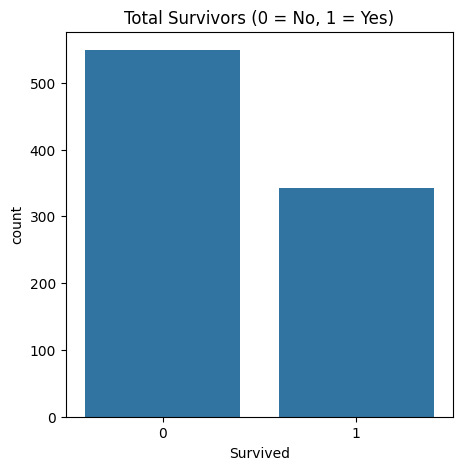

In [33]:
# univariate analysis(column = Survived)
plt.figure(figsize=(5,5))
sns.countplot(x='Survived', data=df)
plt.title('Total Survivors (0 = No, 1 = Yes)')
plt.show()

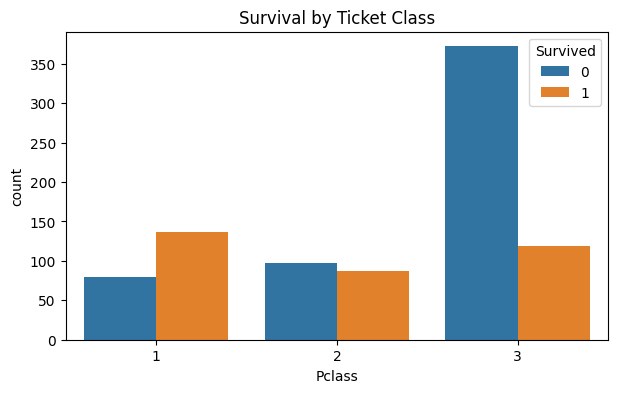

In [34]:
# bivariate analysis (if rich people survives more?) :
plt.figure(figsize=(7, 4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Ticket Class')
plt.show()

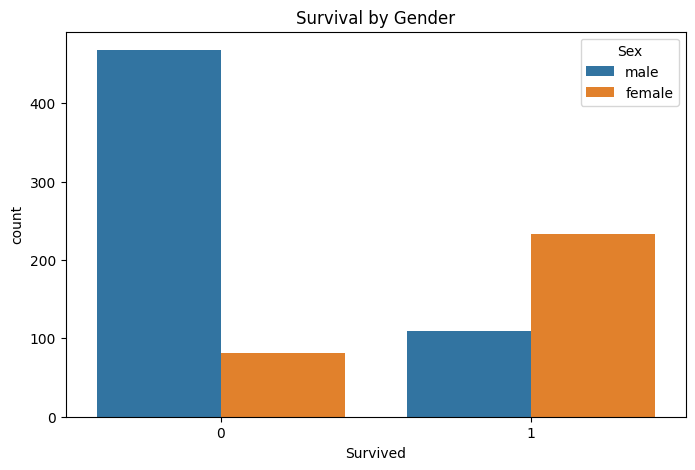

In [4]:
# bivariate analysis (is women & children first conspiracy correct?)
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival by Gender')
plt.savefig('survival_by_gender.png')
plt.show()

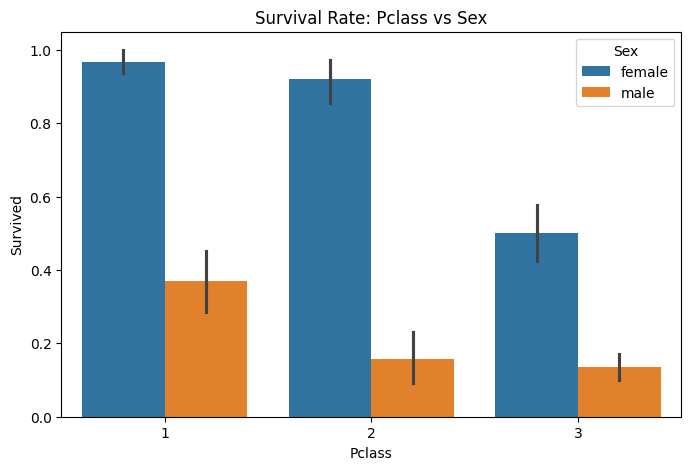

In [36]:
# multivariate analysis (Pclass vs Sex) :
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df)
plt.title('Survival Rate: Pclass vs Sex')
plt.show()

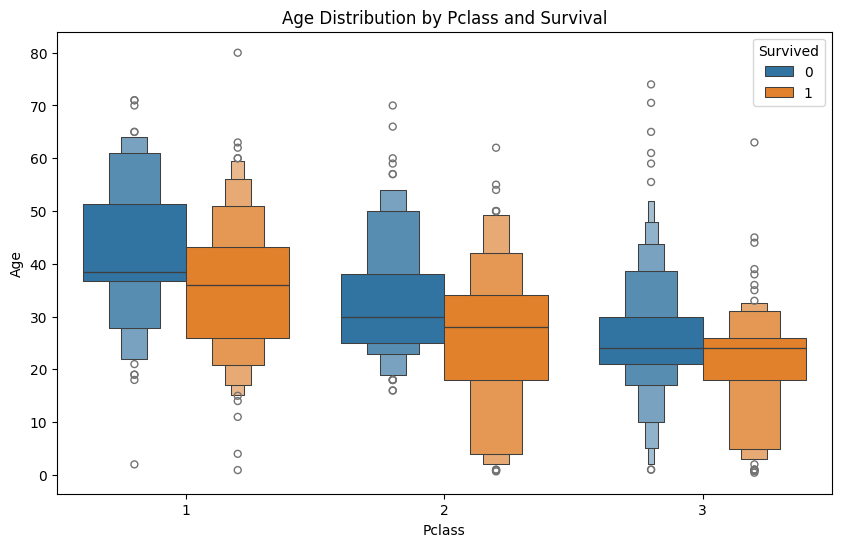

In [37]:
# multivariate analysis (Age vs Pclass vs Survived) :
plt.figure(figsize=(10, 6))
sns.boxenplot(x='Pclass', y='Age', hue='Survived', data=df)
plt.title('Age Distribution by Pclass and Survival')
plt.show()

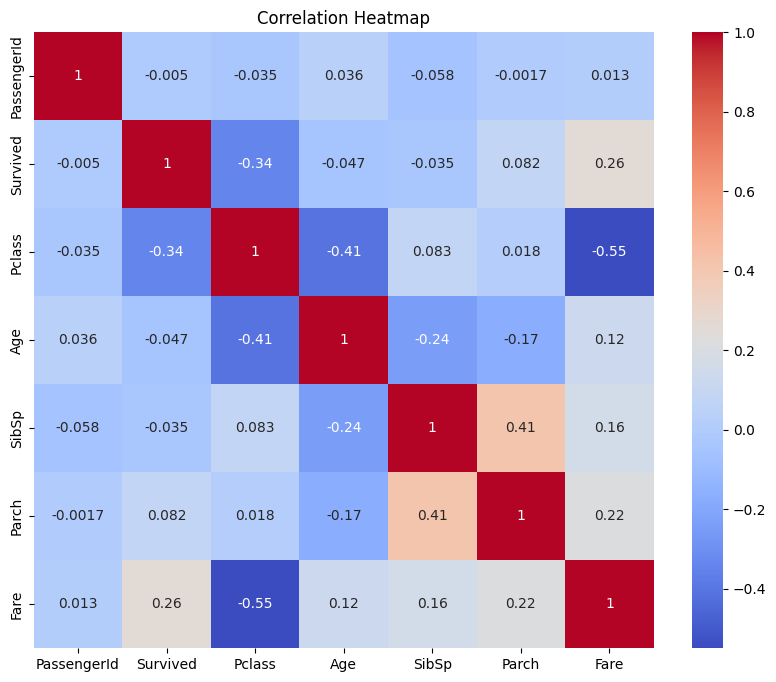

In [38]:
# heatmap :
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Phase 4: Feature Engineering

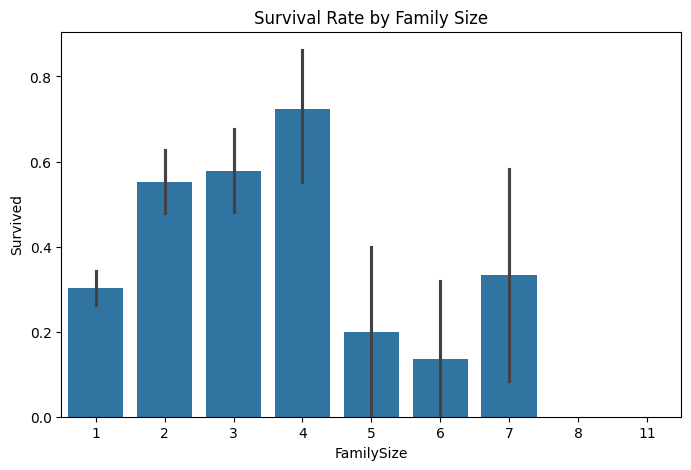

In [50]:
# creating new column 'FamilySize' :
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# is there any effect of family size on survival :
plt.figure(figsize=(8, 5))
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title('Survival Rate by Family Size')
plt.savefig('survival_rate_by_FS.png')
plt.show()

In [44]:
# extracting titles :

# using RegEx :
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
C:\Users\hp\AppData\Local\Temp\ipykernel_1444\660427396.py:4: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


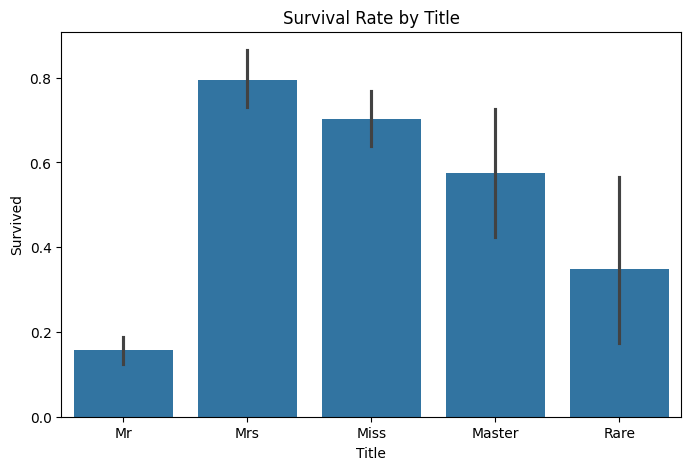

In [46]:
# Converting titles :
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# survival rate by Title
plt.figure(figsize=(8, 5))
sns.barplot(x='Title', y='Survived', data=df)
plt.title('Survival Rate by Title')
plt.show()